# Simple kriging and ordinary kriging

Here we implement simple kriging and ordinary kriging for a case study using variogram parameters from the Variogram Model example. 

Kriging is a deterministic interpolation algorithm, where the goal is to minimize estimation variance, or optimize accuracy. Each interpolated value is the weighted sum of neighboring measurements. These weights are determined using the variogram so that the spatial structure of the data is accounted for. Each interpolated value $Z^*$ at a location $u$ is the weighted sum of neighboring measurements:

$$
    Z^*(u_0) = \sum_{\alpha}^{N} \lambda_{\alpha} Z(u_{\alpha}),
$$

where $\lambda_{\alpha}$ are the weights on the $N$ data points. These weights account for the variability of the measurements, their proximity to each other and the node being estimated, and the redundancy between nearby measurements. The variogram is also used to compute the uncertainty, or variance, at each location. 

$$
    \sigma_E^2(u_0) = C(0) - \sum_{\alpha}^{N} \lambda_{\alpha} C(u_0-u_{\alpha}).
$$

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
import geopandas as gpd
import pyogrio
from shapely import make_valid as shp_make_valid
from mpl_toolkits.axes_grid1 import make_axes_locatable


import skgstat as skg
from skgstat import models
import gstatsim as gs

# plot utility functions
from plot_utils import splot2D, mplot1, mplot2_std

## Load and plot data

Points after clipping: 1590497


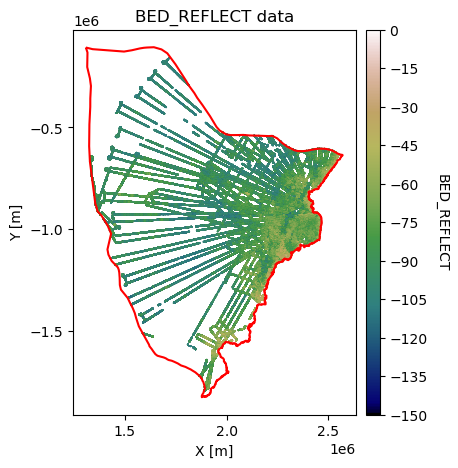

In [2]:
# load data and clip to WilkesLand
gdf = gpd.read_parquet("data/icethk_all.parquet")

wilkes = pyogrio.read_dataframe("data/WilkesLand/WilkesLand.shp", force_2d=True, on_invalid="fix")
wilkes["geometry"] = wilkes.geometry.apply(shp_make_valid)
wilkes = wilkes.set_crs("EPSG:3031").to_crs(gdf.crs)

gdf = gpd.clip(gdf, wilkes)
gdf = gdf.dropna()
print(f"Points after clipping: {len(gdf)}")

# plot the clipped data
field = 'BED_REFLECT'
vmin = -150; vmax = 0

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.scatter(gdf['X'], gdf['Y'], c=gdf[field], vmin=vmin, vmax=vmax,
                marker='.', s=0.5, cmap='gist_earth')
wilkes.boundary.plot(ax=ax, color='red', linewidth=1.5)
plt.title(f'{field} data')
plt.xlabel('X [m]'); plt.ylabel('Y [m]')
plt.locator_params(nbins=5)
plt.axis('scaled')

# make colorbar
from mpl_toolkits.axes_grid1 import make_axes_locatable
divider = make_axes_locatable(ax)
cax = divider.append_axes('right', size='5%', pad=0.1)
cbar = plt.colorbar(im, ticks=np.linspace(vmin, vmax, 11), cax=cax)
cbar.set_label(field, rotation=270, labelpad=15)
plt.show()

## Grid and transform data. Get variogram parameters

See variogram tutorials for details

NEW: returning variogram parameter fits, not just plotting

In [3]:
# --- Fit variogram on 1% sample (fast) ---
df_sample = gdf.sample(frac=0.01, random_state=42)
sample_data = df_sample['BED_REFLECT'].values.reshape(-1,1)
nst_sample = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(sample_data)
df_sample['NBED_REFLECT'] = nst_sample.transform(sample_data)

coords_sample = df_sample[['X','Y']].values
values_sample = df_sample['NBED_REFLECT']

maxlag = 50000
n_lags = 70

V1 = skg.Variogram(coords_sample, values_sample, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)
V1.model = 'matern'
print("Variogram parameters (range, sill, smoothness, nugget):", V1.parameters)

# --- Grid full dataset for kriging ---
res = 10000 #10km grid
df_grid, grid_matrix, rows, cols = gs.Gridding.grid_data(gdf, 'X', 'Y', 'BED_REFLECT', res)
df_grid = df_grid[df_grid["Z"].isnull() == False]
df_grid = df_grid.rename(columns = {"Z": "BED_REFLECT"})

# normal score transformation on full gridded data
data = df_grid['BED_REFLECT'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal").fit(data)
df_grid['NBED_REFLECT'] = nst_trans.transform(data)

print(f"Gridded points for kriging: {len(df_grid)}")

Variogram parameters (range, sill, smoothness, nugget): [np.float64(49999.9886838217), np.float64(0.5063816664438571), np.float64(0.35543373073559764), 0]
Gridded points for kriging: 5101


These outputs are the variogram range, sill, smoothness, and nugget, respectively. We will need this information for kriging.

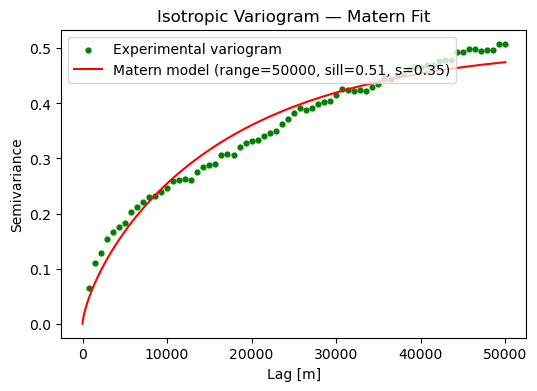

In [4]:
# plot experimental variogram with fitted matern model
vrange = V1.parameters[0]
vsill = V1.parameters[1]
vsmooth = 0.35 # V1.parameters[2]
vnugget = V1.parameters[3]

xdata = V1.bins
ydata = V1.experimental

xi = np.linspace(0, xdata[-1], 1000)
y_model = [models.matern(h, vrange, vsill, vsmooth, vnugget) for h in xi]

plt.figure(figsize=(6,4))
plt.scatter(xdata, ydata, s=12, c='g', label='Experimental variogram')
plt.plot(xi, y_model, '-r', label=f'Matern model (range={vrange:.0f}, sill={vsill:.2f}, s={vsmooth:.2f})')
plt.title('Isotropic Variogram — Matern Fit')
plt.xlabel('Lag [m]'); plt.ylabel('Semivariance')
plt.legend(loc='upper left')
plt.show()

## NEW: Initialize grid

First we need to define a grid to interpolate. This stores an array of coordinates for the simulation.

In [5]:
# define coordinate grid based on full shapefile extent (not just data extent)
wilkes_bounds = wilkes.total_bounds  # [xmin, ymin, xmax, ymax]
xmin = wilkes_bounds[0]; xmax = wilkes_bounds[2]
ymin = wilkes_bounds[1]; ymax = wilkes_bounds[3]

Pred_grid_xy, pred_cols, pred_rows = gs.Gridding.make_grid(xmin, xmax, ymin, ymax, res)
# use prediction grid rows/cols for plotting (may differ from grid_data's rows/cols)
rows = pred_rows
cols = pred_cols
print(f"Prediction grid: {len(Pred_grid_xy)} points, rows={rows}, cols={cols}")

# create mask for cells inside the Wilkes basin shapefile
from shapely.geometry import Point
pred_gdf = gpd.GeoDataFrame(
    geometry=[Point(x, y) for x, y in Pred_grid_xy],
    crs=gdf.crs
)
inside_mask = pred_gdf.within(wilkes.union_all())
print(f"Points inside Wilkes basin: {inside_mask.sum()} of {len(Pred_grid_xy)}")

Prediction grid: 21844 points, rows=172, cols=127
Points inside Wilkes basin: 11784 of 21844


## NEW: Simple kriging

Simple kriging assumes that the mean is stationary and known. The data is treated as a residual from the mean, which is computed as the average of conditioning points. Sometimes this is a good assumption, but in some cases it is not. We will apply it here to see what happens.

In [6]:
# set variogram parameters (matern: range, sill, smoothness, nugget)
azimuth = 0
nugget = V1.parameters[3]

# the major and minor ranges are the same in this example because it is isotropic
major_range = V1.parameters[0]
minor_range = V1.parameters[0]
sill = V1.parameters[1]
s = V1.parameters[2]  # matern smoothness parameter

# save variogram parameters as a list
vario = [azimuth, nugget, major_range, minor_range, sill, 'matern', s]

k = 50         # number of neighboring data points used to estimate a given point
rad = 1000000    # search radius (m)

# est_SK is the estimate and var_SK is the variance
est_SK, var_SK = gs.Interpolation.skrige(Pred_grid_xy, df_grid, 'X', 'Y', 'NBED_REFLECT', k, vario, rad)

100%|██████████| 21844/21844 [01:10<00:00, 310.97it/s]


Although the SciKit-GStat package fits a sill parameter, we prefer to use a sill of 1 because it makes the covariance zero for measurements with lag distances greater than the range, which tends to make simulation algorithms run better. However, you can still substitute in a different sill value if you wish.

Here, k is the number of conditioning nodes used to estimate a grid cell. This means that each estimate will be informed the by k nearby measurements within a specified search radius. The search radius should be at least as large as the largest measurement gap. If you're getting errors, it is usually because the radius is too small. Generally speaking, increasing the search radius and number of conditioning nodes improves the simulation quality.

The simulation is applied to the transformed data, so a reverse normal score transformation must be applied to recover the original distribution.

In [8]:
# reverse normal score transformation

var_SK[var_SK < 0] = 0      # make sure variances are non-negative
std_SK = np.sqrt(var_SK)    # convert to standard deviation before back transforming

# reshape
est = est_SK.reshape(-1,1)
std = std_SK.reshape(-1,1)

# back transformation
spred_trans = nst_trans.inverse_transform(est)
sstd_trans = nst_trans.inverse_transform(std)
sstd_trans = sstd_trans - np.min(sstd_trans)

# mask values outside Wilkes basin
spred_trans[~inside_mask.values] = np.nan
sstd_trans[~inside_mask.values] = np.nan

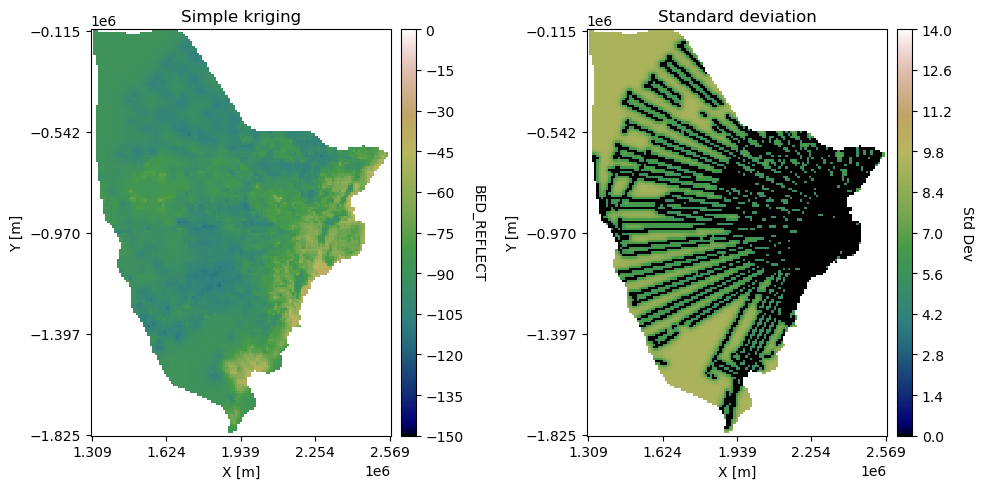

In [9]:
# plot simple kriging and standard deviation
mplot2_std(Pred_grid_xy, spred_trans, sstd_trans,
           rows, cols, title1='Simple kriging', title2='Standard deviation',
           vmin=-150, vmax=0, std_vmin=0, std_vmax=14,
           clabel='BED_REFLECT', std_clabel='Std Dev')

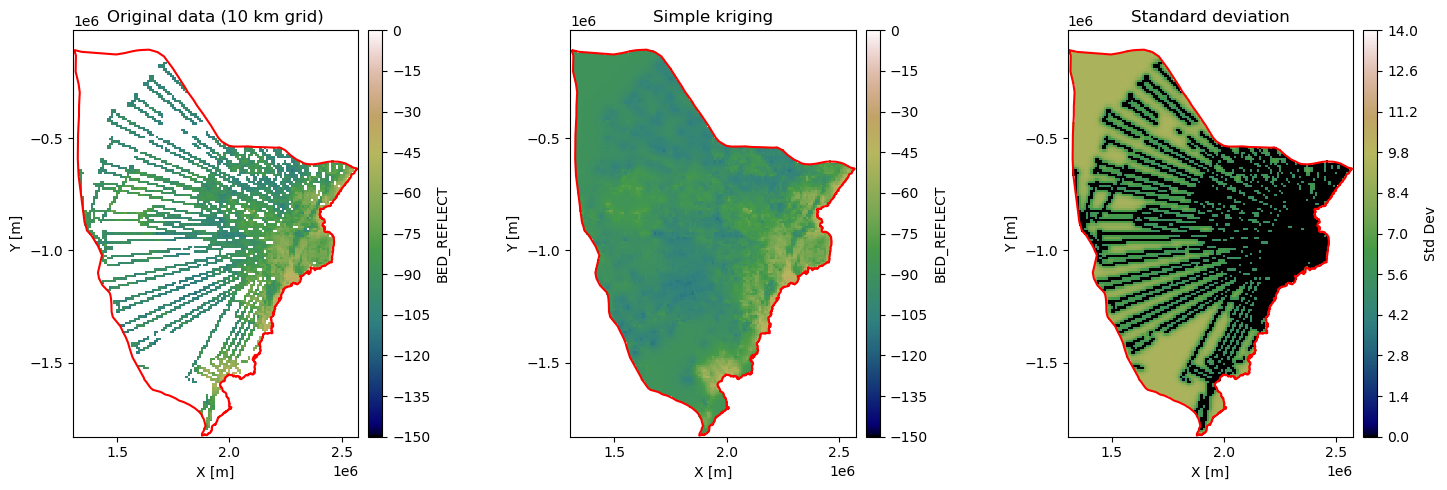

In [19]:
# Fast 3-panel plot: original gridded data, simple kriging, and standard deviation
x_mat = Pred_grid_xy[:,0].reshape((rows, cols))
y_mat = Pred_grid_xy[:,1].reshape((rows, cols))
pred_mat = spred_trans.reshape((rows, cols))
std_mat = sstd_trans.reshape((rows, cols))

# grid original data onto the same prediction grid for fast pcolormesh
orig_grid, _, _, _ = gs.Gridding.grid_data(gdf, 'X', 'Y', 'BED_REFLECT', res)
# place gridded data values onto the full prediction grid (shapefile extent)
orig_on_pred = np.full(len(Pred_grid_xy), np.nan)
for _, row in orig_grid.dropna(subset=['Z']).iterrows():
    # find nearest prediction grid cell
    dists = np.sum((Pred_grid_xy - np.array([row['X'], row['Y']]))**2, axis=1)
    idx = np.argmin(dists)
    if dists[idx] < res**2:  # within one grid cell
        orig_on_pred[idx] = row['Z']
# mask outside shapefile
orig_on_pred[~inside_mask.values] = np.nan
orig_mat = orig_on_pred.reshape((rows, cols))

pred_vmin = -150; pred_vmax = 0
std_vmin = 0; std_vmax = 14

fig, [ax1, ax2, ax3] = plt.subplots(1, 3, figsize=(15, 5))

# panel 1: original data (10 km grid)
im1 = ax1.pcolormesh(x_mat, y_mat, orig_mat, vmin=pred_vmin, vmax=pred_vmax, cmap='gist_earth')
wilkes.boundary.plot(ax=ax1, color='red', linewidth=1.5)
ax1.set_title(f'Original data ({res/1000:.0f} km grid)')
ax1.set_xlabel('X [m]'); ax1.set_ylabel('Y [m]')
ax1.locator_params(nbins=5)
ax1.axis('scaled')
divider1 = make_axes_locatable(ax1)
cax1 = divider1.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im1, ticks=np.linspace(pred_vmin, pred_vmax, 11), cax=cax1, label='BED_REFLECT')

# panel 2: simple kriging
im2 = ax2.pcolormesh(x_mat, y_mat, pred_mat, vmin=pred_vmin, vmax=pred_vmax, cmap='gist_earth')
wilkes.boundary.plot(ax=ax2, color='red', linewidth=1.5)
ax2.set_title('Simple kriging')
ax2.set_xlabel('X [m]'); ax2.set_ylabel('Y [m]')
ax2.locator_params(nbins=5)
ax2.axis('scaled')
divider2 = make_axes_locatable(ax2)
cax2 = divider2.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im2, ticks=np.linspace(pred_vmin, pred_vmax, 11), cax=cax2, label='BED_REFLECT')

# panel 3: standard deviation
im3 = ax3.pcolormesh(x_mat, y_mat, std_mat, vmin=std_vmin, vmax=std_vmax, cmap='gist_earth')
wilkes.boundary.plot(ax=ax3, color='red', linewidth=1.5)
ax3.set_title('Standard deviation')
ax3.set_xlabel('X [m]'); ax3.set_ylabel('Y [m]')
ax3.locator_params(nbins=5)
ax3.axis('scaled')
divider3 = make_axes_locatable(ax3)
cax3 = divider3.append_axes('right', size='5%', pad=0.1)
fig.colorbar(im3, ticks=np.linspace(std_vmin, std_vmax, 11), cax=cax3, label='Std Dev')

plt.tight_layout()
plt.show()

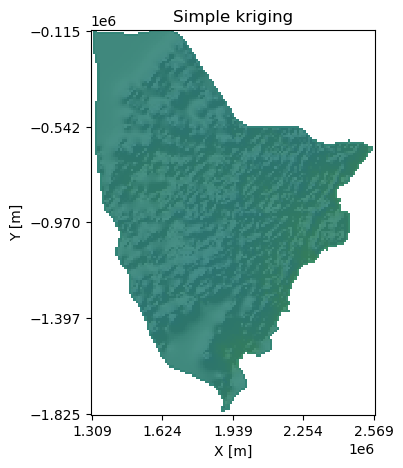

In [11]:
# plot hillshade for visualizing
mplot1(Pred_grid_xy, spred_trans, rows, cols, title='Simple kriging', hillshade=True)

The downside of simple kriging is that it assumes that all the data points are a residual from a constant mean across the area. This could give us a biased estimate, especially if there are differences in data density at different elevations. Let's try ordinary kriging, where the mean is unknown.

## Ordinary kriging

Ordinary kriging (OK) uses a locally varying mean. This makes OK more robust to trends.

In [12]:
k = 100
est_OK, var_OK = gs.Interpolation.okrige(Pred_grid_xy, df_grid, 'X', 'Y', 'NBED_REFLECT', k, vario, rad) # estimation and variance

# reverse normal score transformation
var_OK[var_OK < 0] = 0; # make sure variances are non-negative
std_OK = np.sqrt(var_OK) # convert to standard deviation (this should be done before back transforming!!!)

# reshape
est = est_OK.reshape(-1,1)
std = std_OK.reshape(-1,1)

# back transformation
pred_trans = nst_trans.inverse_transform(est)
std_trans = nst_trans.inverse_transform(std)
std_trans = std_trans - np.min(std_trans)

# mask values outside Wilkes basin
pred_trans[~inside_mask.values] = np.nan
std_trans[~inside_mask.values] = np.nan

100%|██████████| 21844/21844 [01:42<00:00, 213.96it/s]


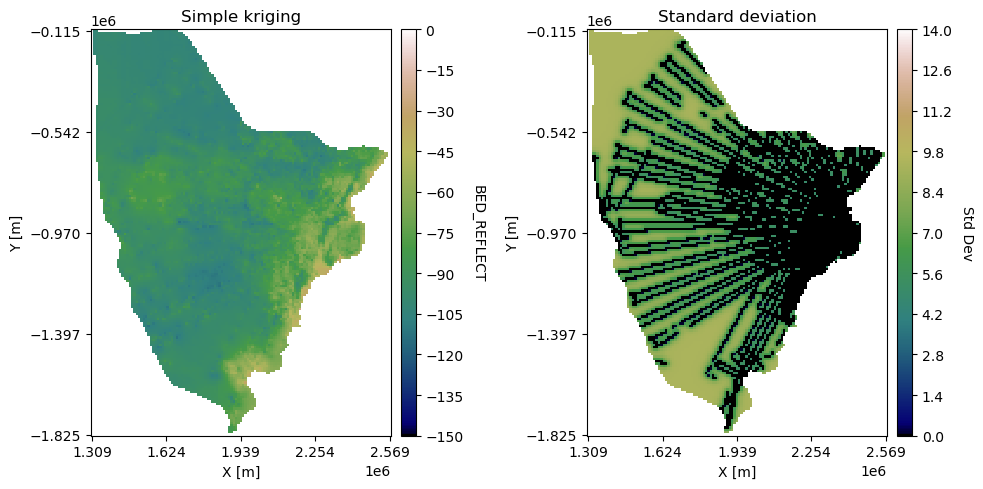

In [ ]:
# plot ordinary kriging and stnadard deviation
# mplot2_std(Pred_grid_xy, pred_trans, std_trans, rows, cols, 
#            title1='Ordinary kriging', title2='Standard deviation')

# plot simple kriging and standard deviation
mplot2_std(Pred_grid_xy, pred_trans, std_trans,
           rows, cols, title1='Standard kriging', title2='Standard deviation',
           vmin=-150, vmax=0, std_vmin=0, std_vmax=14,
           clabel='BED_REFLECT', std_clabel='Std Dev')

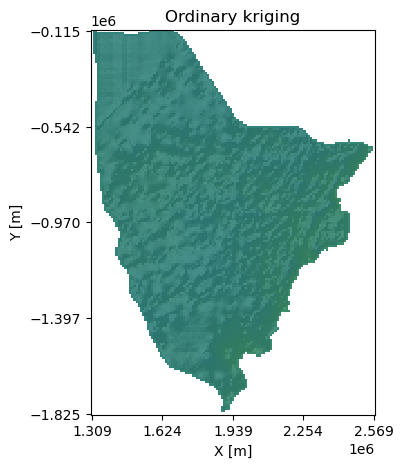

In [14]:
# make hillshade for visualizing
mplot1(Pred_grid_xy, pred_trans, rows, cols, title='Ordinary kriging', hillshade=True)

Here, the righthand side of the ordinary kriging output is higher elevation than the simple kriging map. This is because ordinary kriging accounts for the large-scale trend of increasing elevation from left to right. However, there appear to be some artifacts in this region as well. This is because this area does not have many measurements, making it difficult to reliably estimate the local mean. This issue could be improved by increasing the search radius.

## Difference between simple kriging and ordinary kriging

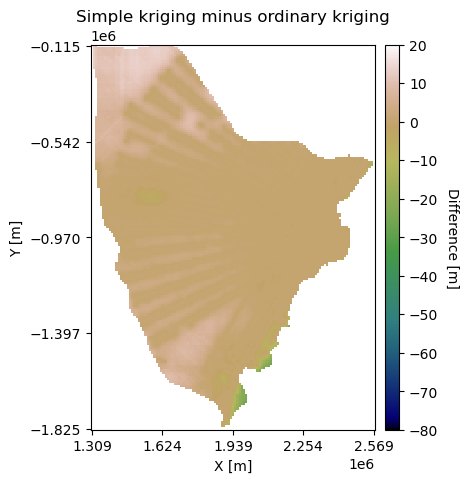

In [15]:
diff = spred_trans - pred_trans
mplot1(Pred_grid_xy, diff, rows, cols, title='Simple kriging minus ordinary kriging', 
       vmin=-80, vmax=20, clabel='Difference [m]')

The differences tend to be the most pronounced in areas that are not near conditioning points.


## Kriging roughness

You'll also notice that parts of kriging outputs look quite smooth. This is because kriging performs interpolations by averaging measurements. Let's compare the variograms of the data and the kriging results to see how they differ.

Notice that we're using the simple kriging values prior to back transfo.rmation because the experimental variogram was computed on normalized data.

In [16]:
# compute simple kriging variogram
coords_s = Pred_grid_xy
values_s = est_SK

VS = skg.Variogram(coords_s, values_s, bin_func='even', n_lags=n_lags, 
                   maxlag=maxlag, normalize=False)

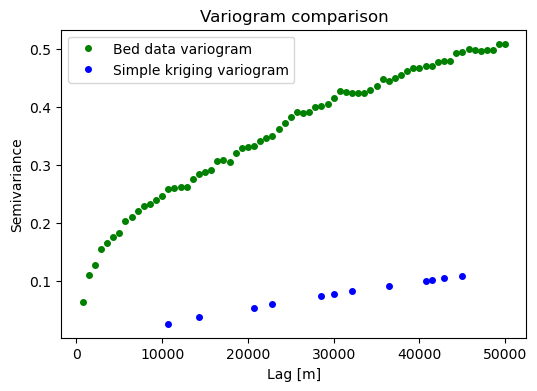

In [17]:
# experimental variogram (from beginning of script)
xe = V1.bins
ye = V1.experimental

# simple kriging variogram
xs = VS.bins
ys = VS.experimental

plt.figure(figsize=(6,4))
plt.plot(xe,ye,'og', markersize=4, label='Bed data variogram')
plt.plot(xs,ys,'ob', markersize=4, label='Simple kriging variogram')
plt.title('Variogram comparison')
plt.xlabel('Lag [m]'); plt.ylabel('Semivariance')  
plt.legend(loc='upper left')
plt.show()

Download the tutorial {Download}`here<./3_Simple_kriging_and_ordinary_kriging.ipynb>`.